# Chapter 14: Clustering and Regionalization

*Part II — Geographic Data Science*

## Learning Objectives

By the end of this chapter you will be able to:

- Group observations into types using ordinary K-Means, and explain why the resulting clusters ignore geography entirely
- Build spatially contiguous regions with `spopt`, and verify contiguity directly rather than taking it on faith
- Explain when each approach is the right tool, instead of defaulting to whichever one is more familiar

## From Detecting Patterns to Grouping Observations

Chapters 12 and 13 both worked with a single variable at a time: does it cluster in space (Moran's I, LISA), and does a regression on it need to account for that clustering (spatial lag, spatial error)? This chapter shifts the question. Given *several* variables at once — say, income and population density for every municipality — which observations resemble each other overall, as a **type**?

That question has two different honest answers, and conflating them is a common mistake. One answer groups by similarity alone, wherever the similar observations happen to sit on the map. The other insists that a group must also be a contiguous block of territory — a legitimate *region*, not just a shared label scattered across the map. Both are useful; they answer different questions.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from libpysal.weights import Queen
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from spopt.region import RegionKMeansHeuristic
import networkx as nx

np.random.seed(7)

## A Synthetic Multivariate Dataset

Following the same reasoning as Chapter 13's synthetic grid, this chapter builds two features — `income` and `density` — with a *known* spatial gradient: both increase smoothly across the grid, plus noise. Real geodemographic variables behave this way constantly (income, health outcomes, housing cost all tend to vary smoothly across a city or state), which is exactly what makes the geography-blind-versus-geography-aware distinction below worth taking seriously rather than treating as a technicality.

In [2]:
n_side = 15
cells_geom = [box(j, i, j + 1, i + 1) for i in range(n_side) for j in range(n_side)]
grid = gpd.GeoDataFrame({"geometry": cells_geom})

xs = np.array([c.centroid.x for c in cells_geom])
ys = np.array([c.centroid.y for c in cells_geom])
grid["income"] = 50 + 3 * xs + np.random.normal(0, 5, len(grid))
grid["density"] = 20 + 2 * ys + np.random.normal(0, 4, len(grid))

w = Queen.from_dataframe(grid, use_index=False)

## Ordinary K-Means: Clusters Blind to Geography

`sklearn.cluster.KMeans` groups rows by distance in *feature* space — `income` and `density` here — with no idea that `grid` has a `geometry` column at all. Four clusters, `k=4`, is a deliberately round number here; Chapter 13's exercises already covered choosing between competing model specifications from diagnostics, and the same spirit (compare against a criterion, don't just pick a number) applies to choosing `k` too, left as an exercise below.

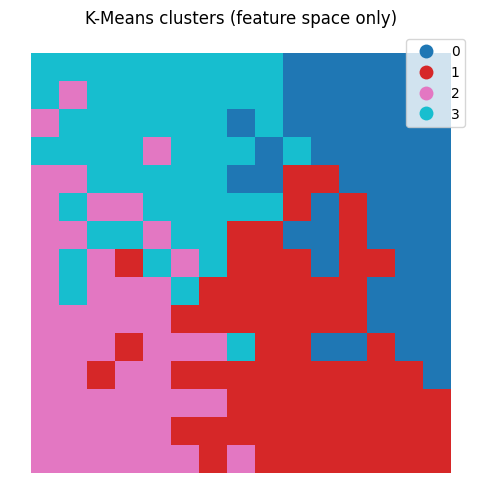

In [3]:
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit(grid[["income", "density"]])
grid["kmeans_cluster"] = km.labels_

fig, ax = plt.subplots(figsize=(6, 6))
grid.plot(column="kmeans_cluster", categorical=True, cmap="tab10", ax=ax, legend=True)
ax.set_title("K-Means clusters (feature space only)")
ax.set_axis_off()

The map answers the question K-Means was actually asked — which cells are similar in `income` and `density` — and nothing more. Whether those similar cells happen to sit next to each other on the map was never part of the objective, so checking it honestly requires actually checking it, not assuming a clustering algorithm run on spatial data automatically produces spatial regions.

In [4]:
# Convert the weights object into a graph and check, cluster by cluster,
# whether its cells form a single connected block
G = w.to_networkx()

contiguous_count = 0
for c in sorted(grid["kmeans_cluster"].unique()):
    idx = np.where(grid["kmeans_cluster"] == c)[0]
    is_contiguous = nx.is_connected(G.subgraph(idx))
    contiguous_count += int(is_contiguous)
    print(f"cluster {c}: n={len(idx)}, contiguous={is_contiguous}")

print(f"\n{contiguous_count} / {grid['kmeans_cluster'].nunique()} K-Means clusters are contiguous")

cluster 0: n=54, contiguous=True
cluster 1: n=66, contiguous=False
cluster 2: n=52, contiguous=False
cluster 3: n=53, contiguous=False

1 / 4 K-Means clusters are contiguous


Only one of the four clusters turns out to be a single connected block — the rest are scattered across two or more separate pieces of the grid, purely because K-Means never had geography as an input in the first place. That is not a bug in K-Means; it is doing exactly what it was asked. It is, however, the wrong tool the moment the actual goal is to draw defensible planning regions, sales territories, or administrative zones.

## Regionalization: Clusters That Respect the Map

Regionalization adds the constraint K-Means never had: every group must be spatially contiguous. `spopt.region.RegionKMeansHeuristic` takes the same feature matrix and the same `w` weights object already built in Chapters 10–13, and searches for clusters under that constraint directly, rather than hoping contiguity shows up by chance.

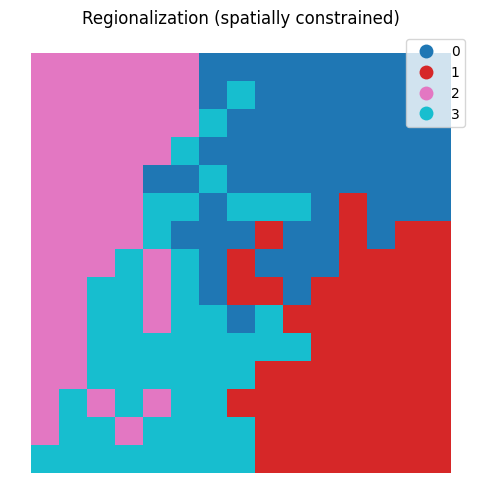

In [5]:
region_model = RegionKMeansHeuristic(grid[["income", "density"]].values, 4, w)
region_model.solve()
grid["region"] = region_model.labels_

fig, ax = plt.subplots(figsize=(6, 6))
grid.plot(column="region", categorical=True, cmap="tab10", ax=ax, legend=True)
ax.set_title("Regionalization (spatially constrained)")
ax.set_axis_off()

In [6]:
all_contiguous = True
for r in sorted(grid["region"].unique()):
    idx = np.where(grid["region"] == r)[0]
    is_contiguous = nx.is_connected(G.subgraph(idx))
    all_contiguous = all_contiguous and is_contiguous
    print(f"region {r}: n={len(idx)}, contiguous={is_contiguous}")

print(f"\nAll regions contiguous: {all_contiguous}")

region 0: n=62, contiguous=True
region 1: n=57, contiguous=True
region 2: n=54, contiguous=True
region 3: n=52, contiguous=True

All regions contiguous: True


Four regions, four contiguous blocks — every time, by construction, not by luck. The trade-off is visible in the map itself: a region absorbs some cells that fit its income/density profile only loosely, because keeping the group in one connected piece sometimes means accepting a slightly worse within-group fit than K-Means would allow. That trade-off is the entire point of regionalization — it optimizes similarity *subject to* contiguity, not similarity alone.

## When to Use Which

The two methods answer genuinely different questions, and the map above makes the difference visible rather than abstract:

- **K-Means** — "Which municipalities are similar, regardless of where they are?" Use it for typologies and market segments: municipalities that behave alike for policy or business purposes, even scattered across a state.
- **Regionalization** — "How do I partition this territory into contiguous zones that are each internally similar?" Use it whenever the output needs to be an actual region someone could draw a boundary around: school districts, sales territories, administrative zones, or — closer to this book's own concerns — spatial units for a simulation model.

## A Bridge to DisSModel's Neighborhoods

Chapter 10 built `Queen` and `Rook` contiguity weights to answer "which cells are neighbors?" for a single cell at a time. Regionalization asks a related but different question at a coarser scale: not a cell's immediate neighbors, but how to partition an entire territory into contiguous, internally coherent blocks. When Chapter 24 introduces `create_neighborhood()` on a `CellularAutomaton`, it is solving a simpler version of exactly this problem — deciding which cells belong together for the purposes of a simulation step. The algorithm there is simpler than `RegionKMeansHeuristic`, but the underlying question — how do you partition space into meaningful, connected units? — is the same one this chapter just answered for static data.

## A Real Example: Economic Typologies vs. Regions in Maranhão

The same `log_pib_pc` and `agro_share` variables from Chapter 13's regression — GDP per capita and agriculture's share of it, for all 217 Maranhão municipalities in 2021 — make a natural two-feature input here too, precisely because Chapter 13 already established that the state has (at least) two distinct economic profiles: the São Luís/Imperatriz commercial corridor and the Balsas/Tasso Fragoso agribusiness belt in the south. K-Means and `RegionKMeansHeuristic` are about to be asked the same question about that pattern that they were asked of the synthetic grid — do the resulting groups actually respect the map — except this time neither the number of "true" types nor their shape is known in advance.

In [2]:
# Same IBGE-URL convention as Chapters 6 and 12 -- no local copy needed
url = (
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/"
    "malhas_territoriais/malhas_municipais/municipio_2025/"
    "UFs/MA/MA_Municipios_2025.zip"
)
maranhao = gpd.read_file(url)

pib = pd.read_csv("pib_municipios_ma.csv")
pop = pd.read_csv("populacao_municipios_ma.csv")

pib_2021 = pib[pib["ano"] == 2021].merge(pop[pop["ano"] == 2021], on=["id_municipio", "ano"])
pib_2021["log_pib_pc"] = np.log(pib_2021["pib"] / pib_2021["populacao"])
pib_2021["agro_share"] = pib_2021["va_agropecuaria"] / pib_2021["pib"]

maranhao["CD_MUN"] = maranhao["CD_MUN"].astype(int)
maranhao = maranhao.merge(
    pib_2021[["id_municipio", "log_pib_pc", "agro_share"]],
    left_on="CD_MUN", right_on="id_municipio", how="left",
)

w_ma = Queen.from_dataframe(maranhao, use_index=False)
G_ma = w_ma.to_networkx()


`log_pib_pc` and `agro_share` sit on very different scales (natural-log GDP versus a 0–1 share), so — unlike the synthetic grid, where `income` and `density` happened to be comparable — this is a case where skipping `StandardScaler` would let GDP alone drive the clustering.

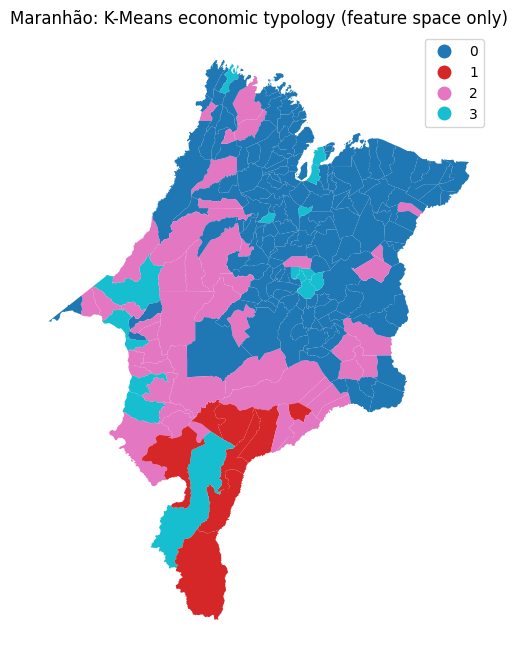

In [8]:
X_ma = StandardScaler().fit_transform(maranhao[["log_pib_pc", "agro_share"]].values)

km_ma = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X_ma)
maranhao["kmeans_cluster"] = km_ma.labels_

fig, ax = plt.subplots(figsize=(6, 8))
maranhao.plot(column="kmeans_cluster", categorical=True, cmap="tab10", ax=ax, legend=True)
ax.set_title("Maranhão: K-Means economic typology (feature space only)")
ax.set_axis_off()


In [9]:
contiguous_count = 0
for c in sorted(maranhao["kmeans_cluster"].unique()):
    idx = np.where(maranhao["kmeans_cluster"] == c)[0]
    is_contiguous = nx.is_connected(G_ma.subgraph(idx))
    contiguous_count += int(is_contiguous)
    print(f"cluster {c}: n={len(idx)}, contiguous={is_contiguous}")

print(f"\n{contiguous_count} / {maranhao['kmeans_cluster'].nunique()} K-Means clusters are contiguous")


cluster 0: n=146, contiguous=False
cluster 1: n=8, contiguous=False
cluster 2: n=47, contiguous=False
cluster 3: n=16, contiguous=False

0 / 4 K-Means clusters are contiguous


Zero of four — an even sharper split than the synthetic grid's one-out-of-four. Tasso Fragoso and Sambaíba, the two most agro-heavy, highest-GDP-per-capita municipalities from Chapter 13's example, land in the same K-Means cluster as a genuine economic *type*: small population, agribusiness-dominated, unusually rich per person — regardless of the roughly 700 km separating some of that type's members across the state. That is a correct answer to the question K-Means was asked, and a useless one for drawing an actual regional boundary.

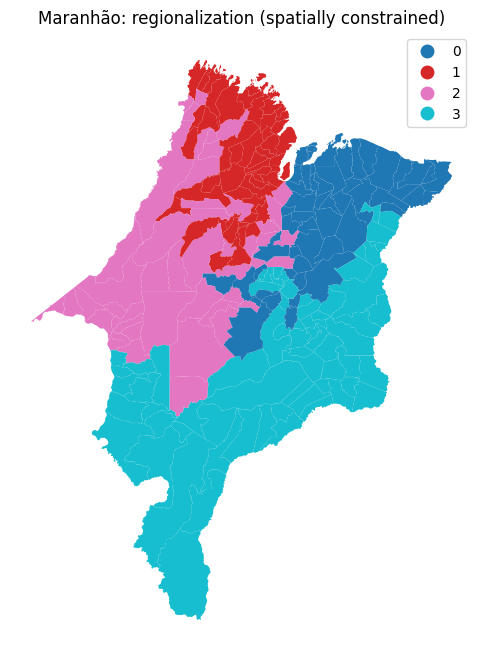

In [10]:
region_model_ma = RegionKMeansHeuristic(X_ma, 4, w_ma)
region_model_ma.solve()
maranhao["region"] = region_model_ma.labels_

fig, ax = plt.subplots(figsize=(6, 8))
maranhao.plot(column="region", categorical=True, cmap="tab10", ax=ax, legend=True)
ax.set_title("Maranhão: regionalization (spatially constrained)")
ax.set_axis_off()


In [11]:
all_contiguous_ma = True
for r in sorted(maranhao["region"].unique()):
    idx = np.where(maranhao["region"] == r)[0]
    is_contiguous = nx.is_connected(G_ma.subgraph(idx))
    all_contiguous_ma = all_contiguous_ma and is_contiguous
    print(f"region {r}: n={len(idx)}, contiguous={is_contiguous}")

print(f"\nAll regions contiguous: {all_contiguous_ma}")


region 0: n=55, contiguous=True
region 1: n=49, contiguous=True
region 2: n=46, contiguous=True
region 3: n=67, contiguous=True

All regions contiguous: True


All four contiguous, as guaranteed — and the trade-off from Section 5 is visible again, more consequentially this time: Balsas, Tasso Fragoso, and Sambaíba now fall into the *same* region, because they are neighbors as well as economic look-alikes, while São Luís and Imperatriz — similar to each other in `agro_share` and grouped together by K-Means — are pulled into two separate regions, since nothing in the state connects the coastal capital to the inland commercial hub except a shared economic profile. Regionalization traded away part of that K-Means-discovered typology specifically to keep every group in one piece — exactly the cost "When to Use Which" described in the abstract, now paid on the state's own economic geography.

## Exercises

1. **Choosing k.** Refit K-Means for `k` in `range(2, 8)` and plot `km.inertia_` against `k` (the "elbow method"). Does a clear elbow appear, or does inertia decrease smoothly without an obvious best `k`?
2. **A LISA-informed feature.** Using the LISA machinery from Chapter 12, compute `Moran_Local` on `income` and add the local statistic (`lisa.Is`) as a third column alongside `income` and `density` before re-running both K-Means and `RegionKMeansHeuristic`. Does adding a spatial-autocorrelation-aware feature change how many K-Means clusters turn out contiguous, even though K-Means still isn't spatially constrained?
3. **Weaker gradient.** Rebuild `income` and `density` with smaller coefficients (e.g. `0.5 * xs` and `0.3 * ys` instead of `3 * xs` and `2 * ys`), keeping the same noise level. Does the contiguity gap between K-Means and regionalization shrink, stay the same, or grow? What does that suggest about when the choice between the two methods matters most?
4. **A different k for regions.** Refit `RegionKMeansHeuristic` with `n_clusters=6` instead of `4`. Are all six regions still contiguous? Does any region become implausibly small or thin?

## Summary

### Key concepts introduced

- The distinction between grouping by similarity alone (K-Means) and grouping by similarity *subject to* spatial contiguity (regionalization)
- `sklearn.cluster.KMeans` on multivariate geographic data, and why its clusters are not automatically spatially coherent — verified directly via `networkx`, not assumed
- `spopt.region.RegionKMeansHeuristic`, which reuses the same `libpysal` weights object from Chapters 10–13 to guarantee every group is a single connected block
- A practical criterion for choosing between the two: does the output need to be an actual region someone could draw a boundary around?
- Regionalization as a static preview of the spatial-partitioning problem Chapter 24's `create_neighborhood()` solves dynamically, inside a running simulation
- A real check against Maranhão's 2021 economic data: K-Means found zero of four clusters contiguous (grouping Tasso Fragoso and Sambaíba together as an "agro-elite" type despite the distance between them), while `RegionKMeansHeuristic` traded that typology for four genuinely contiguous regions, splitting São Luís and Imperatriz apart despite their economic similarity

Chapter 15 turns from statistics back to communication — the mapping and visualization techniques for presenting exactly the kind of pattern the last three chapters learned to detect, model, and now group.

## Further Reading

- Sergio J. Rey, Dani Arribas-Bel, and Levi J. Wolf, *Geographic Data Science with Python* (CRC Press) — freely available at <https://geographicdata.science/book/>; see their chapter on clustering and regionalization for the same K-Means/regionalization distinction applied to real San Diego census tracts
- Duque, J. C., Church, R. L., & Middleton, R. S. (2011). "The p-Regions Problem." *Geographical Analysis*, 43(1), 104-126 — the regionalization problem this chapter's `RegionKMeansHeuristic` is one heuristic solution to
- scikit-learn documentation, *K-Means*: <https://scikit-learn.org/stable/modules/clustering.html#k-means>
- spopt documentation, *Region*: <https://pysal.org/spopt/notebooks/reg-kmeans-heuristic.html>
- IBGE, *Produto Interno Bruto dos Municípios* — the same GDP and sectoral value-added source Chapter 13 used for Maranhão's `log_pib_pc` and `agro_share`: <https://www.ibge.gov.br/estatisticas/economicas/contas-nacionais/9088-produto-interno-bruto-dos-municipios.html>